In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
# More imports
from tensorflow.keras.layers import Input, SimpleRNN, GRU, LSTM, Dense, Flatten, GlobalMaxPool1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
### build the dataset
# This is a nonlinear AND long-distance dataset
# (Actually, we will test long-distance vs. short-distance patterns)

# Start with a small T and increase it later
T = 10
D = 1
X = []
Y = []

def get_label(x, i1, i2, i3):
  # x = sequence
  if x[i1] < 0 and x[i2] < 0 and x[i3] < 0:
    return 1
  if x[i1] < 0 and x[i2] > 0 and x[i3] > 0:
    return 1
  if x[i1] > 0 and x[i2] < 0 and x[i3] > 0:
    return 1
  if x[i1] > 0 and x[i2] > 0 and x[i3] < 0:
    return 1
  return 0

for t in range(5000):
  x = np.random.randn(T)
  X.append(x)
  y = get_label(x, -1, -2, -3) # short distance
#   y = get_label(x, 0, 1, 2) # long distance
  Y.append(y)

X = np.array(X)
Y = np.array(Y)
N = len(X)

In [4]:
# Try a linear model first - note: it is classification now!
i = Input(shape=(T,))
x = Dense(1, activation='sigmoid')(i)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy'],
)

# train the network
r = model.fit(
  X, Y,
  epochs=100,
  validation_split=0.5,
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4704 - loss: 0.7904 - val_accuracy: 0.4968 - val_loss: 0.7019
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5028 - loss: 0.6979 - val_accuracy: 0.5052 - val_loss: 0.6942
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5040 - loss: 0.6950 - val_accuracy: 0.4984 - val_loss: 0.6947
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5044 - loss: 0.6949 - val_accuracy: 0.5076 - val_loss: 0.6950
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5156 - loss: 0.6951 - val_accuracy: 0.5096 - val_loss: 0.6945
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4992 - loss: 0.6954 - val_accuracy: 0.5080 - val_loss: 0.6943
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5044 - loss: 0.6953 - val_accuracy: 0.4956 - val_loss: 0.6955
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5076 - loss: 0.6954 - val_accuracy: 0.5092 - v

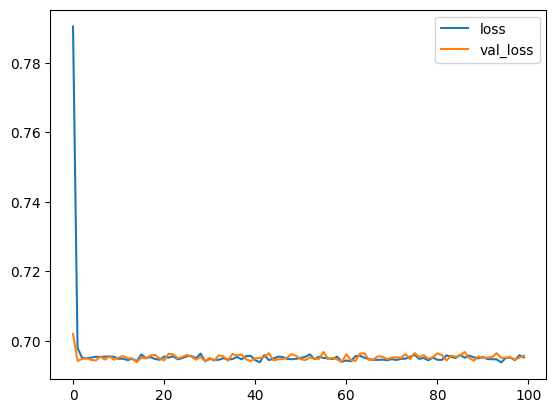

In [5]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

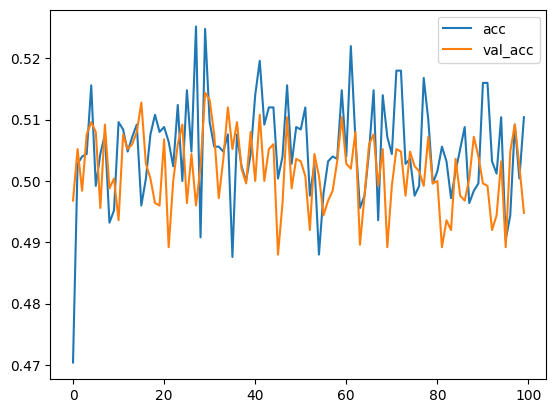

In [6]:
# Plot the accuracy too - should be around 50%
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [7]:
# Now try a simple RNN
inputs = np.expand_dims(X, -1)

# make the RNN
i = Input(shape=(T, D))

# method 1
# x = LSTM(5)(i)
x = SimpleRNN(5)(i)
# x = GRU(5)(i)

# method 2
# x = LSTM(5, return_sequences=True)(i)
# x = GlobalMaxPool1D()(x)

x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  # optimizer='rmsprop',
#   optimizer='adam',
  optimizer=Adam(learning_rate=0.01),
  # optimizer=SGD(learning_rate=0.1, momentum=0.9),
  metrics=['accuracy'],
)
# train the RNN
r = model.fit(
  inputs, Y,
  epochs=200,
  validation_split=0.5,
)

Epoch 1/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5120 - loss: 0.7201 - val_accuracy: 0.5168 - val_loss: 0.6920
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5232 - loss: 0.6922 - val_accuracy: 0.5364 - val_loss: 0.6907
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5380 - loss: 0.6882 - val_accuracy: 0.5552 - val_loss: 0.6836
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5704 - loss: 0.6761 - val_accuracy: 0.6484 - val_loss: 0.6603
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6796 - loss: 0.6345 - val_accuracy: 0.7252 - val_loss: 0.6054
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7744 - loss: 0.5566 - val_accuracy: 0.8080 - val_loss: 0.5055
Epoch 7/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8264 - loss: 0.4633 - val_accuracy: 0.8620 - val_loss: 0.3975
Epoch 8/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8728 - loss: 0.3685 - val_accuracy: 0.9000

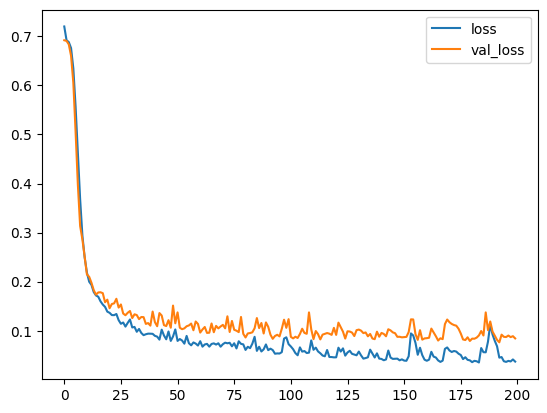

In [8]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

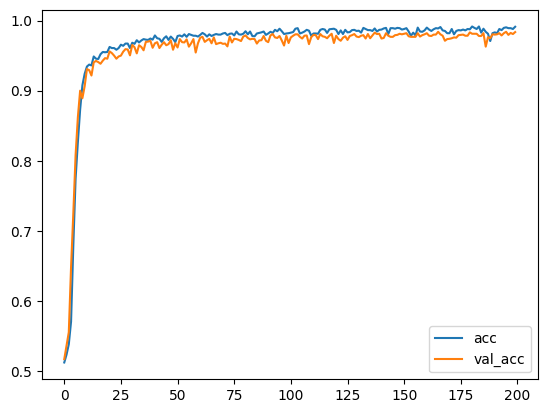

In [9]:
# Plot the accuracy too
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [10]:
# Now change to the long distance problem

# Start with a small T and increase it later
T = 10
D = 1
X = []
Y = []

for t in range(5000):
  x = np.random.randn(T)
  X.append(x)
  y = get_label(x, 0, 1, 2) # long distance
  Y.append(y)

X = np.array(X)
Y = np.array(Y)
N = len(X)
# Now test our Simple RNN again
inputs = np.expand_dims(X, -1)

# make the RNN
i = Input(shape=(T, D))

# method 1
x = SimpleRNN(5)(i)

x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy'],
)

# train the RNN
r = model.fit(
  inputs, Y,
  epochs=200,
  validation_split=0.5,
)

Epoch 1/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5088 - loss: 0.7074 - val_accuracy: 0.4924 - val_loss: 0.6972
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5092 - loss: 0.6951 - val_accuracy: 0.5056 - val_loss: 0.6945
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5204 - loss: 0.6939 - val_accuracy: 0.5048 - val_loss: 0.6967
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5232 - loss: 0.6931 - val_accuracy: 0.5076 - val_loss: 0.6960
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5148 - loss: 0.6938 - val_accuracy: 0.5024 - val_loss: 0.6968
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5244 - loss: 0.6918 - val_accuracy: 0.5096 - val_loss: 0.6965
Epoch 7/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5236 - loss: 0.6914 - val_accuracy: 0.5096 - val_loss: 0.6953
Epoch 8/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5316 - loss: 0.6869 - val_accuracy: 0.5636 

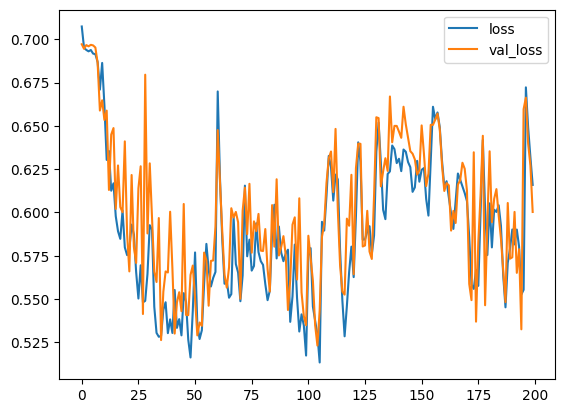

In [11]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

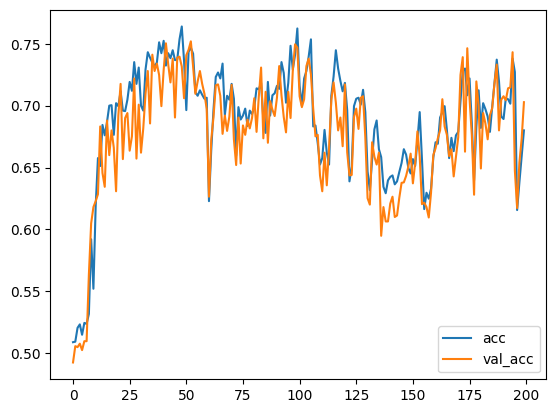

In [12]:
# Plot the accuracy too
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [13]:
# Now test our LSTM
inputs = np.expand_dims(X, -1)

# make the RNN
i = Input(shape=(T, D))

# method 1
x = LSTM(5)(i)

x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy'],
)

# train the RNN
r = model.fit(
  inputs, Y,
  epochs=200,
  validation_split=0.5,
)

Epoch 1/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4964 - loss: 0.6944 - val_accuracy: 0.4860 - val_loss: 0.6939
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5076 - loss: 0.6934 - val_accuracy: 0.5048 - val_loss: 0.6934
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5072 - loss: 0.6933 - val_accuracy: 0.4860 - val_loss: 0.6945
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4972 - loss: 0.6927 - val_accuracy: 0.4944 - val_loss: 0.6945
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4992 - loss: 0.6924 - val_accuracy: 0.5112 - val_loss: 0.6936
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5180 - loss: 0.6919 - val_accuracy: 0.4964 - val_loss: 0.6955
Epoch 7/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5040 - loss: 0.6920 - val_accuracy: 0.4848 - val_loss: 0.6971
Epoch 8/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5136 - loss: 0.6918 - val_accuracy: 0.4928

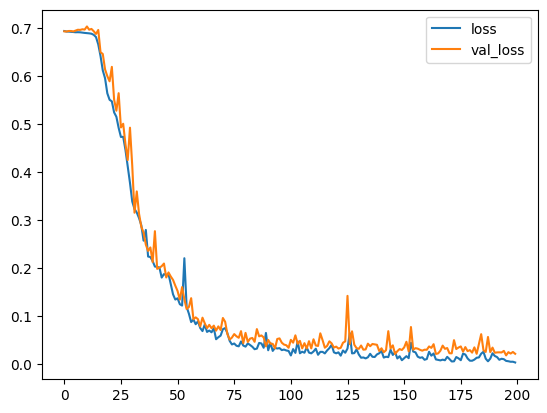

In [14]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

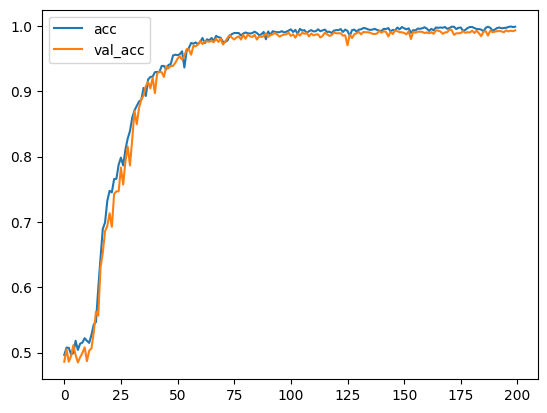

In [15]:
# Plot the accuracy too
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [16]:
# Make the problem harder by making T larger
T = 20
D = 1
X = []
Y = []

for t in range(5000):
  x = np.random.randn(T)
  X.append(x)
  y = get_label(x, 0, 1, 2) # long distance
  Y.append(y)

X = np.array(X)
Y = np.array(Y)
N = len(X)
# Now test our Simple RNN again
inputs = np.expand_dims(X, -1)

# make the RNN
i = Input(shape=(T, D))

# method 1
x = SimpleRNN(5)(i)

x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy'],
)

# train the RNN
r = model.fit(
  inputs, Y,
  epochs=200,
  validation_split=0.5,
)

Epoch 1/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5024 - loss: 0.6963 - val_accuracy: 0.4868 - val_loss: 0.6944
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5124 - loss: 0.6937 - val_accuracy: 0.5048 - val_loss: 0.6970
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5240 - loss: 0.6934 - val_accuracy: 0.4892 - val_loss: 0.6974
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5204 - loss: 0.6932 - val_accuracy: 0.4908 - val_loss: 0.6973
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5216 - loss: 0.6935 - val_accuracy: 0.4936 - val_loss: 0.6979
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5264 - loss: 0.6915 - val_accuracy: 0.4924 - val_loss: 0.6950
Epoch 7/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5140 - loss: 0.6933 - val_accuracy: 0.4968 - val_loss: 0.6975
Epoch 8/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5188 - loss: 0.6922 - val_accuracy: 0.4888 - 

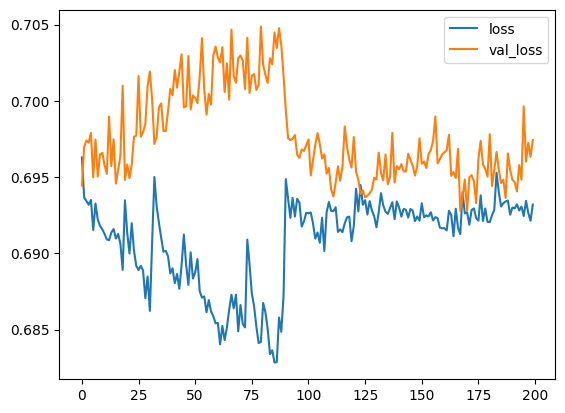

In [17]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

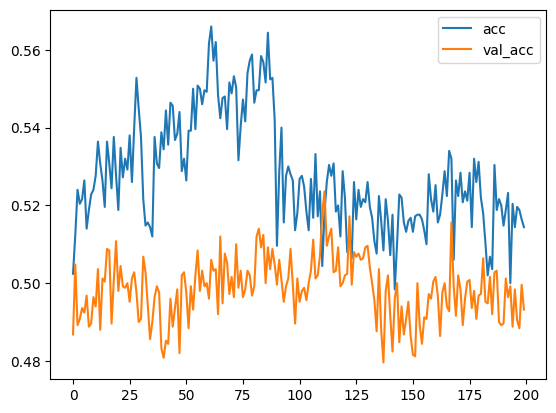

In [18]:
# Plot the accuracy too
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [19]:
# Now test our LSTM
inputs = np.expand_dims(X, -1)

# make the RNN
i = Input(shape=(T, D))

# method 1
x = LSTM(5)(i)

x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy'],
)

# train the RNN
r = model.fit(
  inputs, Y,
  epochs=200,
  validation_split=0.5,
)

Epoch 1/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5212 - loss: 0.6939 - val_accuracy: 0.4928 - val_loss: 0.6948
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5128 - loss: 0.6933 - val_accuracy: 0.4868 - val_loss: 0.6948
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5232 - loss: 0.6925 - val_accuracy: 0.4904 - val_loss: 0.6951
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5160 - loss: 0.6919 - val_accuracy: 0.4836 - val_loss: 0.6971
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5272 - loss: 0.6924 - val_accuracy: 0.5140 - val_loss: 0.6938
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5180 - loss: 0.6921 - val_accuracy: 0.4968 - val_loss: 0.6950
Epoch 7/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5252 - loss: 0.6919 - val_accuracy: 0.5024 - val_loss: 0.6964
Epoch 8/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5248 - loss: 0.6915 - val_accuracy: 0.

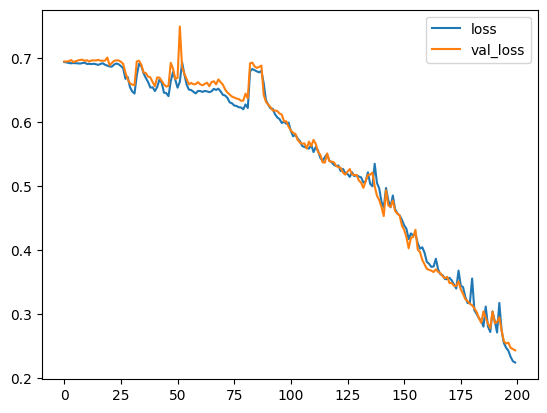

In [20]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

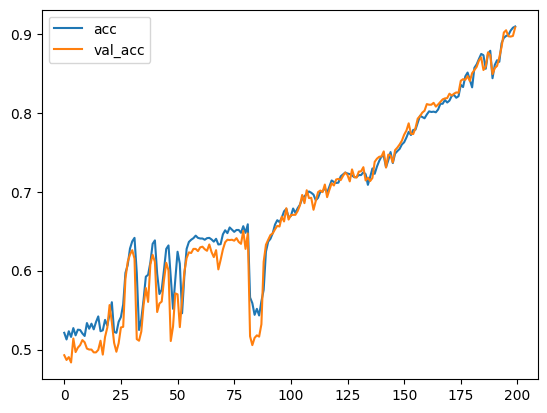

In [21]:
# Plot the accuracy too
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [22]:
# Now test our GRU
inputs = np.expand_dims(X, -1)

# make the RNN
i = Input(shape=(T, D))

# method 1
x = GRU(5)(i)

x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy'],
)

# train the RNN
r = model.fit(
  inputs, Y,
  epochs=400,
  validation_split=0.5,
)

Epoch 1/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5056 - loss: 0.6934 - val_accuracy: 0.5024 - val_loss: 0.6938
Epoch 2/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5156 - loss: 0.6931 - val_accuracy: 0.4980 - val_loss: 0.6941
Epoch 3/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5284 - loss: 0.6930 - val_accuracy: 0.5092 - val_loss: 0.6938
Epoch 4/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5132 - loss: 0.6932 - val_accuracy: 0.5092 - val_loss: 0.6931
Epoch 5/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5144 - loss: 0.6928 - val_accuracy: 0.5084 - val_loss: 0.6933
Epoch 6/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5108 - loss: 0.6925 - val_accuracy: 0.5104 - val_loss: 0.6938
Epoch 7/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5100 - loss: 0.6938 - val_accuracy: 0.5096 - val_loss: 0.6934
Epoch 8/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5168 - loss: 0.6927 - val_accuracy: 0.

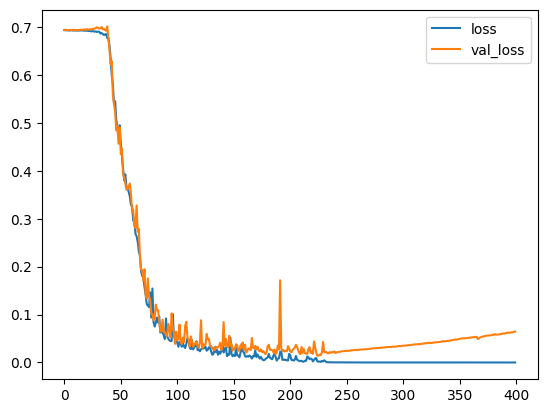

In [23]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

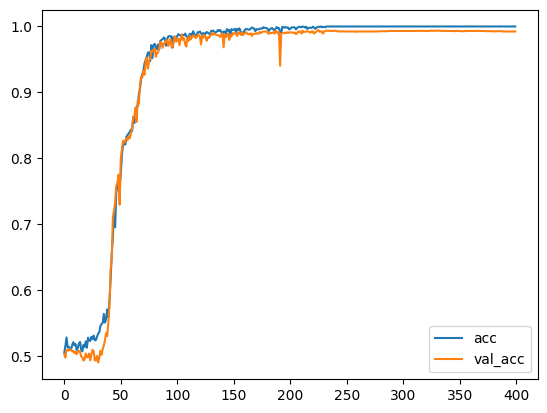

In [24]:
# Plot the accuracy too
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [25]:
# Make the problem harder by making T larger
T = 30
D = 1
X = []
Y = []

for t in range(5000):
  x = np.random.randn(T)
  X.append(x)
  y = get_label(x, 0, 1, 2) # long distance
  Y.append(y)

X = np.array(X)
Y = np.array(Y)
N = len(X)

In [26]:
# Now test our LSTM
inputs = np.expand_dims(X, -1)

# make the RNN
i = Input(shape=(T, D))

# method 1
x = LSTM(15)(i)

x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy'],
)

# train the RNN
r = model.fit(
  inputs, Y,
  epochs=400,
  validation_split=0.5,
)

Epoch 1/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4908 - loss: 0.6943 - val_accuracy: 0.5080 - val_loss: 0.6931
Epoch 2/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4884 - loss: 0.6935 - val_accuracy: 0.5048 - val_loss: 0.6931
Epoch 3/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4980 - loss: 0.6934 - val_accuracy: 0.5084 - val_loss: 0.6942
Epoch 4/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5032 - loss: 0.6934 - val_accuracy: 0.5088 - val_loss: 0.6932
Epoch 5/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5116 - loss: 0.6931 - val_accuracy: 0.5072 - val_loss: 0.6931
Epoch 6/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5080 - loss: 0.6931 - val_accuracy: 0.5076 - val_loss: 0.6933
Epoch 7/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5088 - loss: 0.6934 - val_accuracy: 0.5100 - val_loss: 0.6930
Epoch 8/400
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4960 - loss: 0.6930 - val_accuracy: 0.

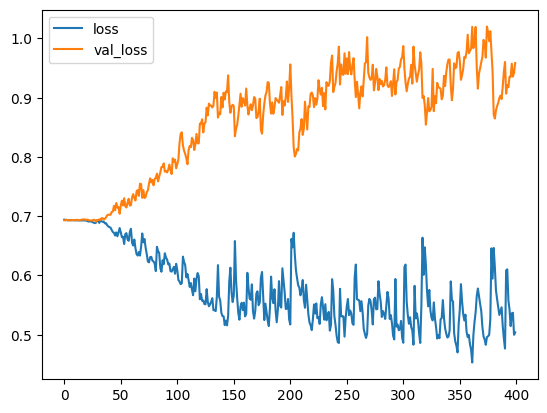

In [27]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

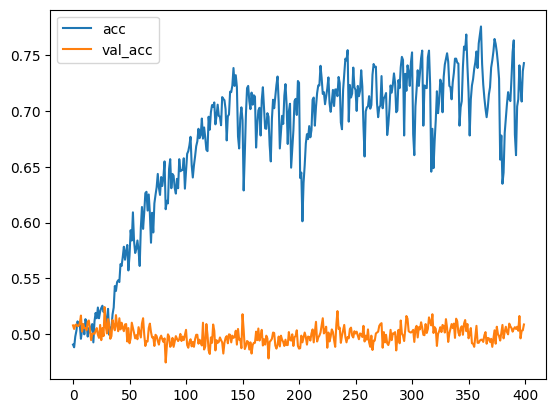

In [28]:
# Plot the accuracy too
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [29]:
# Now try a LSTM with Global Max Pooling
inputs = np.expand_dims(X, -1)

# make the RNN
i = Input(shape=(T, D))

# method 2
x = LSTM(5, return_sequences=True)(i)
x = GlobalMaxPool1D()(x)

x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy'],
)

# train the RNN
r = model.fit(
  inputs, Y,
  epochs=100,
  validation_split=0.5,
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5084 - loss: 0.6943 - val_accuracy: 0.4956 - val_loss: 0.7010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4840 - loss: 0.6963 - val_accuracy: 0.5036 - val_loss: 0.6934
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5188 - loss: 0.6925 - val_accuracy: 0.5040 - val_loss: 0.6935
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5196 - loss: 0.6914 - val_accuracy: 0.5228 - val_loss: 0.6907
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5272 - loss: 0.6906 - val_accuracy: 0.5200 - val_loss: 0.6894
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5332 - loss: 0.6898 - val_accuracy: 0.5192 - val_loss: 0.6941
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5232 - loss: 0.6917 - val_accuracy: 0.5284 - val_loss: 0.6885
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5516 - loss: 0.6862 - val_accuracy: 0.

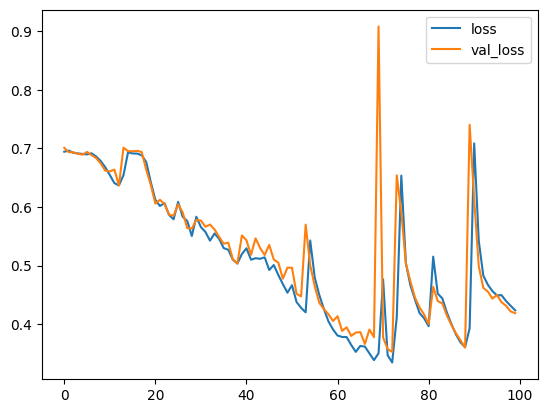

In [30]:
# Plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

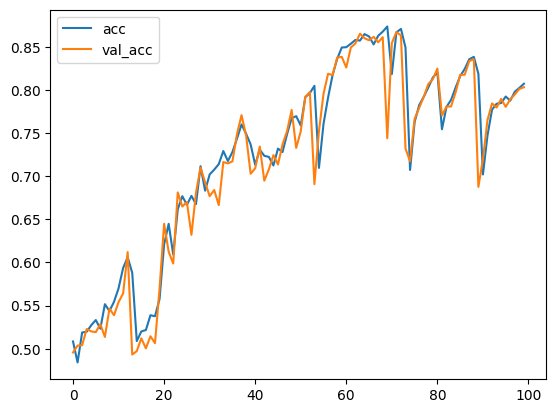

In [31]:
# Plot the accuracy too
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()